<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:30px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 127 · Solutions</div>
  <div style="font-size:30px;font-weight:900;line-height:1.1;margin:10px 0 6px">Components of a Time Series &#183; Solutions</div>
  <div style="font-size:14px;color:#e0f2fe;max-width:740px;line-height:1.6">Five challenges, each verified in code.</div>

</div>

# Components of a Time Series &#183; Challenge Solutions
Worked solutions to the five practice challenges from Chapter 127. Each loads the same monthly-sales series and answers with a short, library-first block using **statsmodels** and **pandas**.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings; warnings.filterwarnings('ignore')
try: raw = pd.read_excel('../../data/ch127_monthly_retail_sales.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'ch127_monthly_retail_sales.xlsx', sheet_name='Data')
raw['month']=pd.to_datetime(raw['month']); s = raw.set_index('month')['sales'].asfreq('MS')
print('loaded', len(s), 'monthly points')

loaded 72 monthly points


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 1</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Year-over-year growth</div>
<div style="color:#4a5578;margin-top:5px">Compute the 12-month percent change and report the average annual growth rate.</div>
</div>

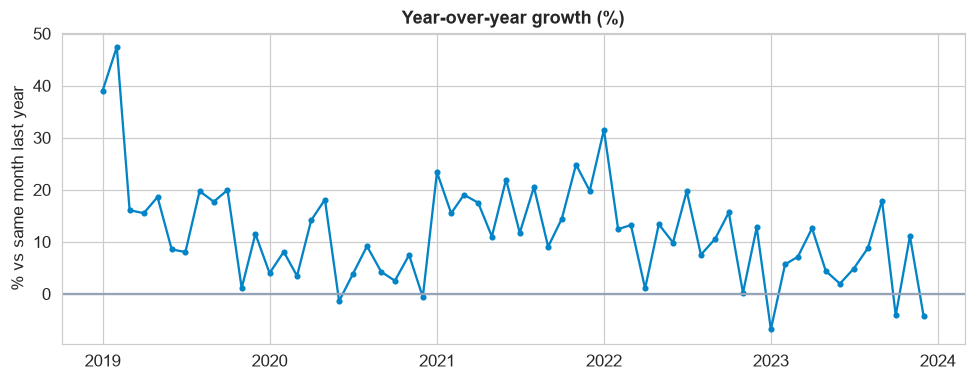

average YoY growth: 11.9%


In [3]:
yoy = s.pct_change(12) * 100
fig,ax=plt.subplots(figsize=(9,3.6)); ax.plot(yoy.index, yoy.values, color=EM, marker='o', ms=3); ax.axhline(0,color=GREY)
ax.set(title='Year-over-year growth (%)', ylabel='% vs same month last year'); plt.tight_layout(); plt.show()
print('average YoY growth: %.1f%%' % yoy.mean())

Comparing each month to the **same month a year earlier** cancels seasonality automatically (both share the December bump), leaving a clean read on growth, here averaging around **12 percent** a year.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 2</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">The seasonal profile</div>
<div style="color:#4a5578;margin-top:5px">Chart the average sales by calendar month and name the peak and trough.</div>
</div>

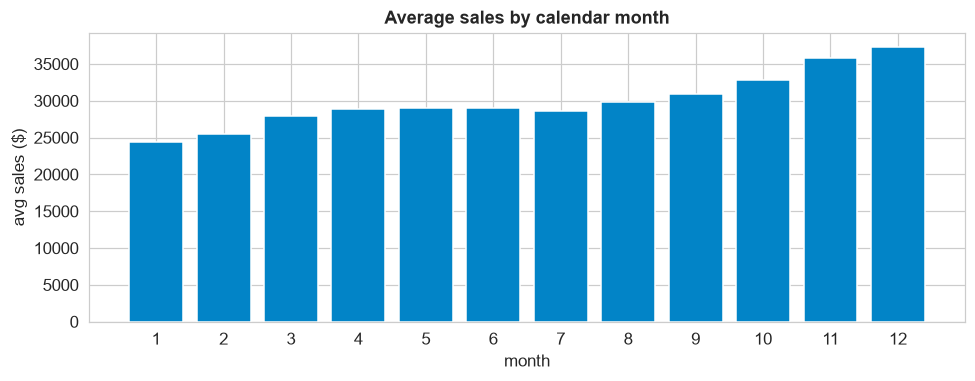

peak month: 12 | trough month: 1


In [4]:
prof = s.groupby(s.index.month).mean()
fig,ax=plt.subplots(figsize=(9,3.6)); ax.bar(prof.index, prof.values, color=EM)
ax.set(title='Average sales by calendar month', xlabel='month', ylabel='avg sales ($)'); ax.set_xticks(range(1,13))
plt.tight_layout(); plt.show()
print('peak month:', int(prof.idxmax()), '| trough month:', int(prof.idxmin()))

Averaging every January, every February, and so on gives the **seasonal profile**. December towers over the rest and January is the low, the holiday shopping signature.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 3</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Additive or multiplicative?</div>
<div style="color:#4a5578;margin-top:5px">Decompose both ways and compare how flat the residuals are.</div>
</div>

In [5]:
add = seasonal_decompose(s, model='additive', period=12)
mult = seasonal_decompose(s, model='multiplicative', period=12)
print('additive residual std (relative):      %.4f' % (np.nanstd(add.resid)/s.mean()))
print('multiplicative residual std (unitless): %.4f' % np.nanstd(mult.resid))
print('both are small and flat here -> additive is a fair, simpler choice for this series')

additive residual std (relative):      0.0395
multiplicative residual std (unitless): 0.0413
both are small and flat here -> additive is a fair, simpler choice for this series


When the seasonal swing is a roughly **constant dollar amount** (not a growing percentage), the **additive** model fits and is simpler to read. If the wave grew with the trend, multiplicative, or modeling `log(sales)`, would win.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 4</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Make it stationary</div>
<div style="color:#4a5578;margin-top:5px">Difference the series and test with ADF; try a seasonal difference too.</div>
</div>

In [6]:
def adf(x,label): p=adfuller(x.dropna())[1]; print(f'{label:24s} ADF p = {p:.3f} -> {"stationary" if p<0.05 else "NON-stationary"}')
adf(s, 'raw')
adf(s.diff(), 'first difference d1')
adf(s.diff(12), 'seasonal difference d12')
print('\nfirst-differencing removes the TREND and passes ADF; a seasonal difference (lag 12) targets the yearly pattern')

raw                      ADF p = 0.903 -> NON-stationary
first difference d1      ADF p = 0.021 -> stationary
seasonal difference d12  ADF p = 0.118 -> NON-stationary

first-differencing removes the TREND and passes ADF; a seasonal difference (lag 12) targets the yearly pattern


**Differencing** (each value minus the previous) strips the trend and flips the ADF verdict from non-stationary (p about 0.90) to stationary (p about 0.02). A **seasonal difference** at lag 12 is the tool aimed specifically at the yearly cycle, both reappear as the `d` and `D` orders in a seasonal ARIMA.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:14px 18px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#075985;letter-spacing:1px">CHALLENGE 5</span>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin-top:3px">Autocorrelation vs white noise</div>
<div style="color:#4a5578;margin-top:5px">Plot the ACF and PACF and find the seasonal lag; contrast with white noise.</div>
</div>

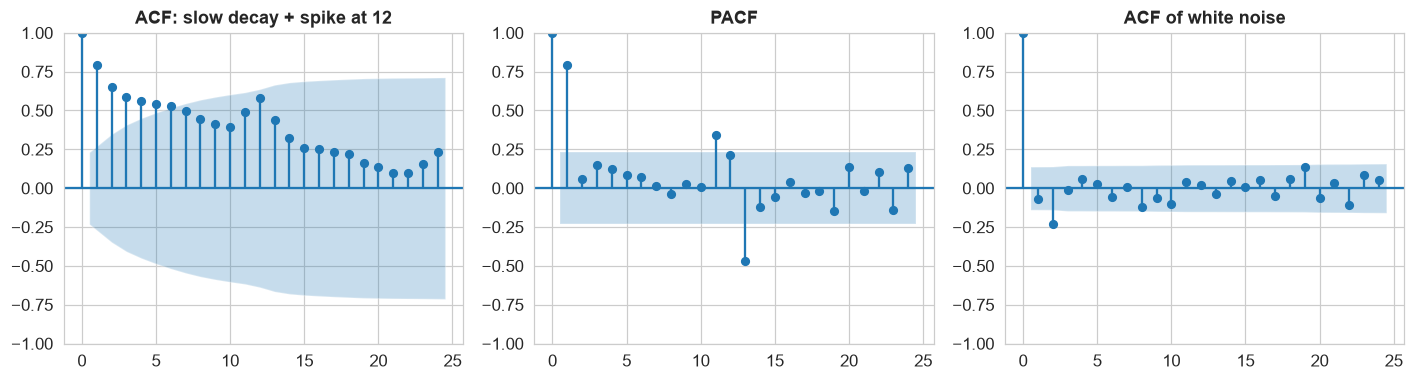

sales ACF lag-1 = 0.79, lag-12 = 0.58 (seasonal echo); white-noise ACF ~ 0 everywhere


In [7]:
fig,ax=plt.subplots(1,3,figsize=(13,3.6))
plot_acf(s.dropna(), lags=24, ax=ax[0]); ax[0].set(title='ACF: slow decay + spike at 12')
plot_pacf(s.dropna(), lags=24, ax=ax[1], method='ywm'); ax[1].set(title='PACF')
wn = pd.Series(np.random.default_rng(1).normal(size=200)); plot_acf(wn, lags=24, ax=ax[2]); ax[2].set(title='ACF of white noise')
plt.tight_layout(); plt.show()
print('sales ACF lag-1 = %.2f, lag-12 = %.2f (seasonal echo); white-noise ACF ~ 0 everywhere' % (acf(s.dropna(),nlags=12)[1], acf(s.dropna(),nlags=12)[12]))

The **ACF** decays slowly (strong trend memory) and spikes at **lag 12**, the fingerprint of yearly seasonality; the **PACF** helps pick model orders in the next chapter. **White noise** has no such structure, every bar sits inside the confidence band, which is exactly what good model residuals should look like.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>